In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("netflix_titles.csv")

print(df.head())
print(df.shape)

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df['director'].fillna("Unknown", inplace=True)
df['cast'].fillna("Not Available", inplace=True)
df['country'].fillna("Not Available", inplace=True)
df['date_added'].fillna("Not Available", inplace=True)
df['rating'].fillna("Not Available", inplace=True)
df['duration'].fillna("Not Available", inplace=True)

df.dropna(subset=['rating'], inplace=True)

/tmp/ipykernel_1309/4262363396.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna("Unknown", inplace=True)
/tmp/ipykernel_1309/4262363396.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

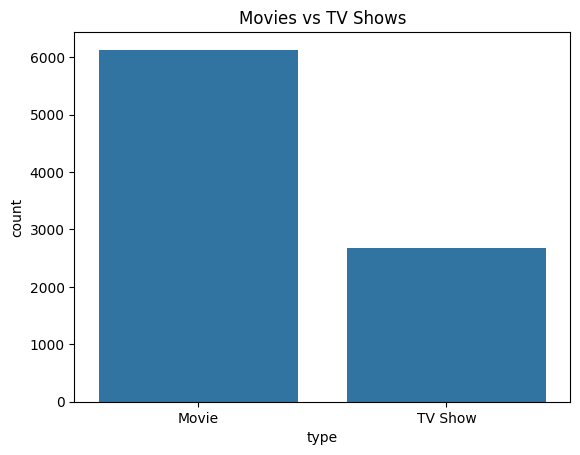

In [ ]:
sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows")
plt.show()

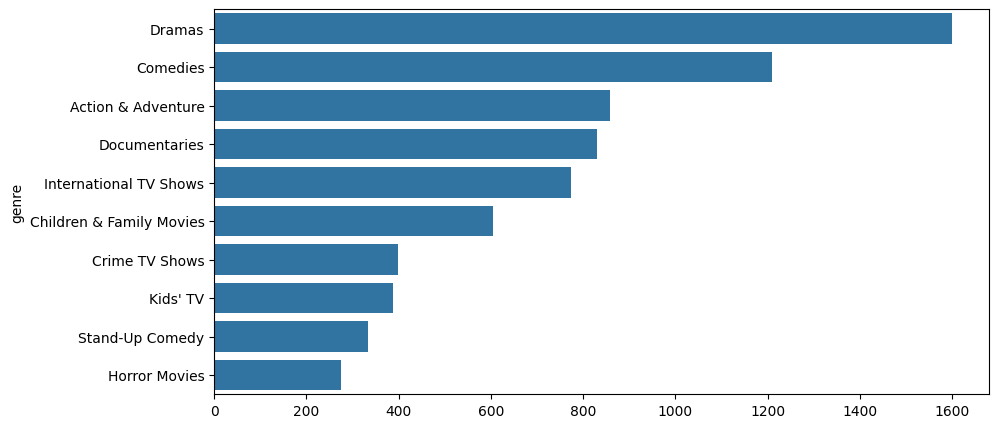

In [ ]:
df['genre'] = df['listed_in'].apply(
    lambda x: x.split(",")[0]
)

top=df['genre'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
x=top.values,
y=top.index
)

plt.show()

In [ ]:
def recommend(movie_name):

    genres=set(
        df[df['title']==movie_name]
        ['listed_in']
        .values[0]
        .split(', ')
    )

    temp=df[df['title']!=movie_name].copy()

    temp['score']=temp['listed_in'].apply(
        lambda x:
        len(
            genres &
            set(x.split(', '))
        )
    )

    return temp.sort_values(
        by='score',
        ascending=False
    )[
    ['title','listed_in','score']
    ].head(5)
print(recommend("Kota Factory"))

                        title  \
7468                Miss Rose   
5356               Love Storm   
1038           Dancing Angels   
6663  Easy Fortune Happy Life   
5026               Best Lover   

                                              listed_in  score  
7468  International TV Shows, Romantic TV Shows, TV ...      3  
5356  International TV Shows, Romantic TV Shows, TV ...      3  
1038  International TV Shows, Romantic TV Shows, TV ...      3  
6663  International TV Shows, Romantic TV Shows, TV ...      3  
5026  International TV Shows, Romantic TV Shows, TV ...      3  


In [ ]:
print(recommend("Narcos"))

                   title                                         listed_in  \
7729  Person of Interest  Crime TV Shows, TV Action & Adventure, TV Dramas   
2415  Queen of the South  Crime TV Shows, TV Action & Adventure, TV Dramas   
2874      Altered Carbon  Crime TV Shows, TV Action & Adventure, TV Dramas   
2921      Narcos: Mexico  Crime TV Shows, TV Action & Adventure, TV Dramas   
3477              Gotham  Crime TV Shows, TV Action & Adventure, TV Dramas   

      score  
7729      3  
2415      3  
2874      3  
2921      3  
3477      3  


In [ ]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['genre_encoded'] = le.fit_transform(df['genre'])

print(df[['genre','genre_encoded']].head())

                    genre  genre_encoded
0           Documentaries             10
1  International TV Shows             16
2          Crime TV Shows              8
3              Docuseries             11
4  International TV Shows             16


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['genre'] = df['listed_in'].apply(
    lambda x: x.split(",")[0]
)

df['type_encoded'] = le.fit_transform(df['type'])

df['genre_encoded'] = le.fit_transform(df['genre'])

df['rating_encoded'] = le.fit_transform(df['rating'])

In [ ]:
df['duration_num'] = (
    df['duration']
    .str.extract('(\d+)')
)

df['duration_num'] = pd.to_numeric(
    df['duration_num'],
    errors='coerce'
)

df['duration_num'].fillna(
    df['duration_num'].median(),
    inplace=True
)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1309/194593493.py:3: SyntaxWarning: invalid escape sequence '\d'
  .str.extract('(\d+)')
/tmp/ipykernel_1309/194593493.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['duration_num'].fillna(


In [ ]:
X = df[
[
'release_year',
'duration_num',
'type_encoded',
'genre_encoded',
'rating_encoded'
]
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

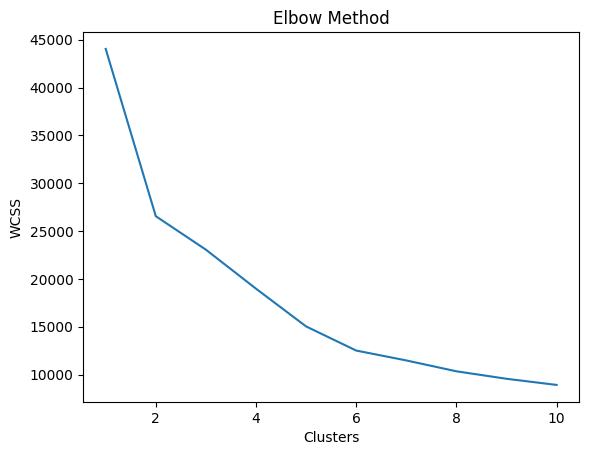

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss=[]

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(
    X_scaled
)

In [ ]:
print(
df[['title','cluster']].head()
)

                   title  cluster
0   Dick Johnson Is Dead        4
1          Blood & Water        2
2              Ganglands        0
3  Jailbirds New Orleans        0
4           Kota Factory        2


In [ ]:
def recommend(movie_name):

    cluster = df[
        df['title']==movie_name
    ]['cluster'].values[0]

    recommendations = df[
        (df['cluster']==cluster)
        &
        (df['title']!=movie_name)
    ]

    return recommendations[
        ['title','genre','cluster']
    ].head(5)

In [ ]:
recommend("Kota Factory")

,title,genre,cluster
1,Blood & Water,International TV Shows,2
5,Midnight Mass,TV Dramas,2
15,Dear White People,TV Comedies,2
19,Jaguar,International TV Shows,2
21,Resurrection: Ertugrul,International TV Shows,2


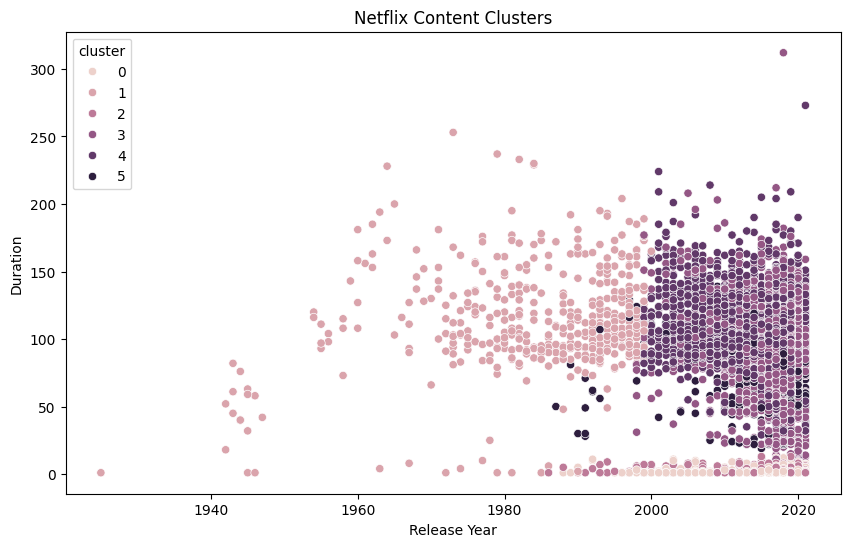

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='release_year',
    y='duration_num',
    hue='cluster',
    data=df
)

plt.title("Netflix Content Clusters")
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.show()

In [ ]:
centroids = kmeans.cluster_centers_

centroids_original = scaler.inverse_transform(centroids)

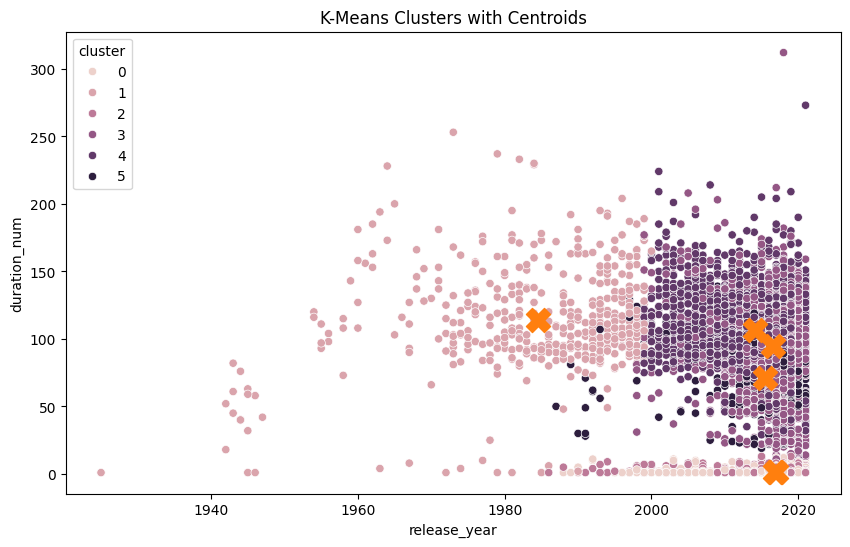

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='release_year',
    y='duration_num',
    hue='cluster',
    data=df
)

plt.scatter(
    centroids_original[:,0],
    centroids_original[:,1],
    s=300,
    marker='X'
)

plt.title("K-Means Clusters with Centroids")

plt.show()

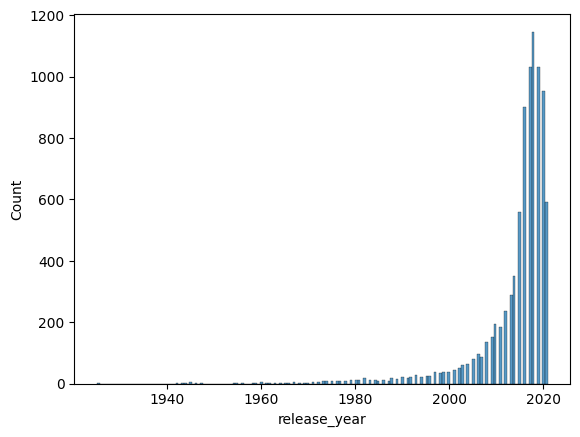

In [ ]:
sns.histplot(df['release_year'])
plt.show()

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Not Available,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

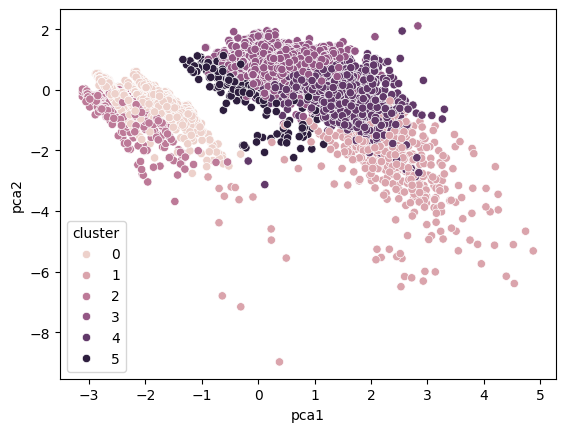

In [ ]:
sns.scatterplot(
    x='pca1',
    y='pca2',
    hue='cluster',
    data=df
)

plt.show()

In [ ]:
print(
df.groupby('cluster')[
['release_year','duration_num']
].mean()
)

         release_year  duration_num
cluster                            
0         2016.793508      1.733425
1         1984.522124    113.949115
2         2016.933168      1.789604
3         2016.523642     94.443142
4         2014.059443    106.608352
5         2015.453975     71.060669


In [ ]:
print(
df.groupby('cluster')['genre']
.value_counts()
)

cluster  genre           
0        Crime TV Shows      399
         Kids' TV            314
         British TV Shows    249
         Docuseries          219
         Anime Series        173
                            ... 
5        Movies               47
         Music & Musicals     18
         Sci-Fi & Fantasy     13
         Romantic Movies       3
         Sports Movies         1
Name: count, Length: 68, dtype: int64


In [ ]:
def recommend(movie_name):

    movie_name = movie_name.strip().lower()

    df['title_lower'] = (
        df['title']
        .str.lower()
    )

    if movie_name not in df['title_lower'].values:
        return "Movie not found"

    cluster = df[
        df['title_lower']==movie_name
    ]['cluster'].values[0]

    recommendations = df[
        (df['cluster']==cluster)
        &
        (df['title_lower']!=movie_name)
    ]

    return recommendations[
        ['title','genre']
    ].head(5)
recommend("Kota Factory")

,title,genre
1,Blood & Water,International TV Shows
5,Midnight Mass,TV Dramas
15,Dear White People,TV Comedies
19,Jaguar,International TV Shows
21,Resurrection: Ertugrul,International TV Shows


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    df['cluster']
)

print(score)

0.33648342323723507


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        "K =",k,
        "Score =",score
    )

K = 2 Score = 0.4367622009935909
K = 3 Score = 0.4278310563030803
K = 4 Score = 0.3018961528224104
K = 5 Score = 0.3049145301555318
K = 6 Score = 0.33648342323723507
K = 7 Score = 0.32178931008086487
K = 8 Score = 0.33273168141180154
K = 9 Score = 0.3288023772172019
K = 10 Score = 0.3417596111978538


In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(
    eps=0.8,
    min_samples=5
)

df['dbscan_cluster']=db.fit_predict(
    X_scaled
)

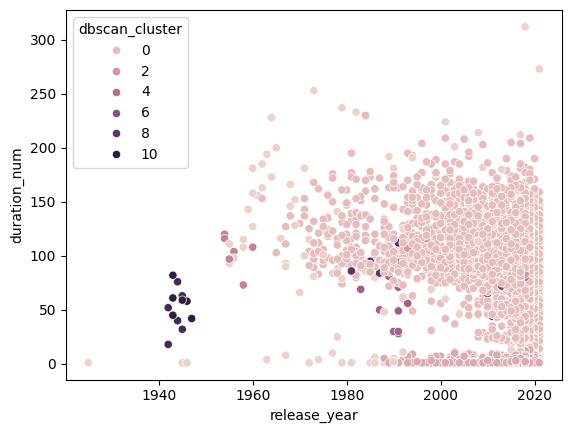

In [ ]:
sns.scatterplot(
x='release_year',
y='duration_num',
hue='dbscan_cluster',
data=df
)

plt.show()

In [ ]:
X = df[
[
'release_year',
'duration_num',
'type_encoded',
'genre_encoded',
'rating_encoded'
]
]

y = df['cluster']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
pred = dt.predict(
    X_test
)

In [ ]:
from sklearn.metrics import accuracy_score

print(
accuracy_score(
y_test,
pred
)
)

0.9960272417707151


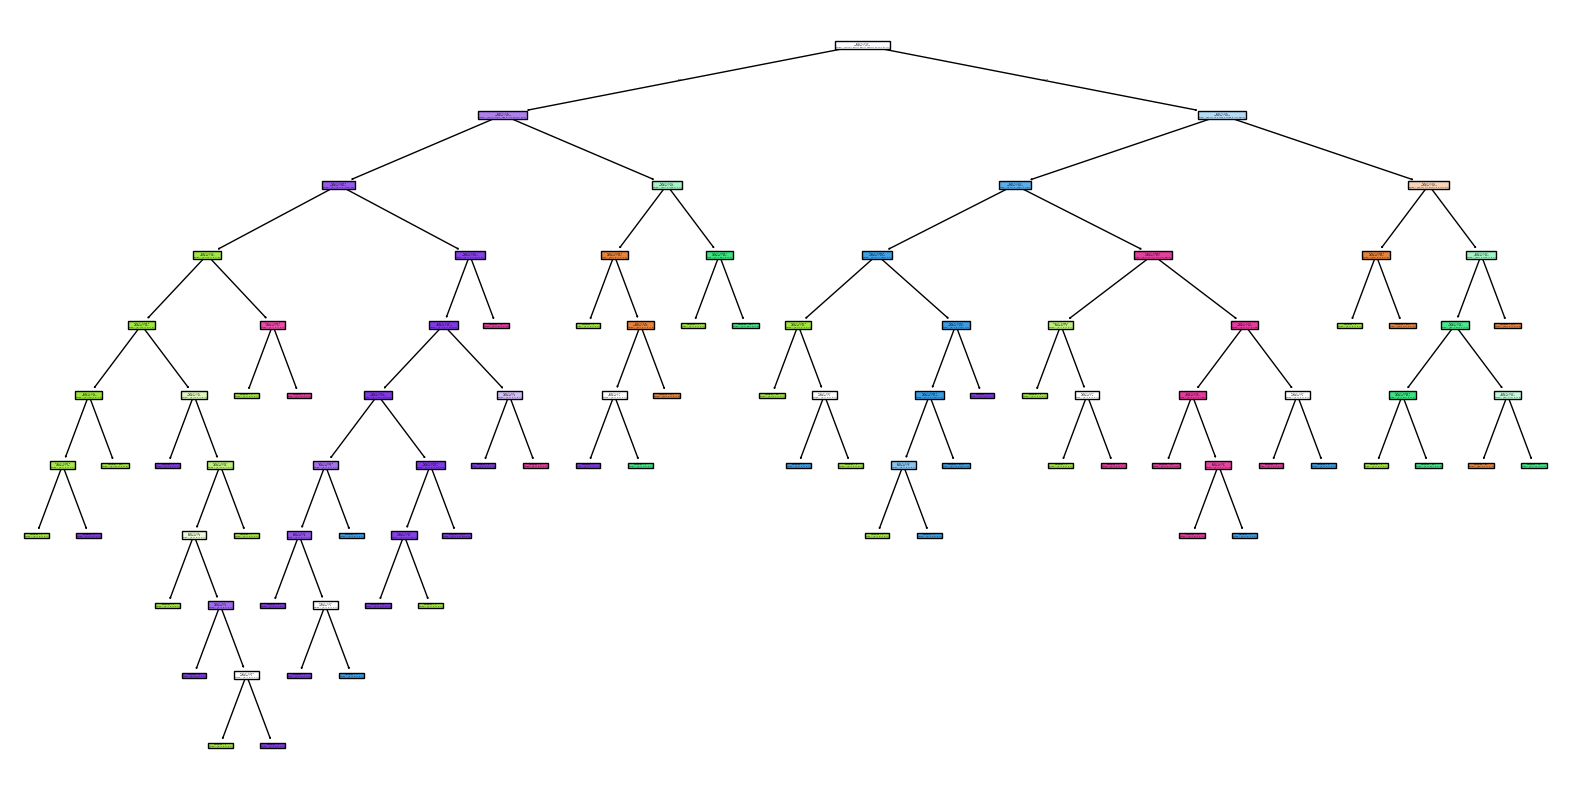

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
dt,
filled=True
)

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       313
           1       0.99      0.98      0.99       102
           2       1.00      1.00      1.00       231
           3       1.00      1.00      1.00       504
           4       1.00      0.99      1.00       511
           5       0.98      0.99      0.99       101

    accuracy                           1.00      1762
   macro avg       0.99      0.99      0.99      1762
weighted avg       1.00      1.00      1.00      1762



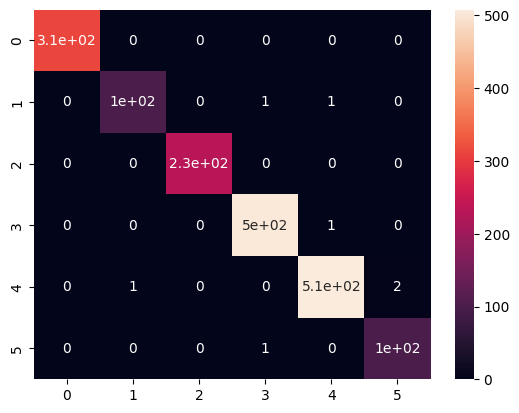

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred
)

sns.heatmap(
    cm,
    annot=True
)

plt.show()

In [ ]:
importance = pd.DataFrame({
'Feature':X.columns,
'Importance':dt.feature_importances_
})

print(
importance.sort_values(
by='Importance',
ascending=False
))

          Feature  Importance
2    type_encoded    0.330355
4  rating_encoded    0.315737
3   genre_encoded    0.240321
0    release_year    0.110829
1    duration_num    0.002758


In [ ]:
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 0     5940
 1     2648
-1      107
 2       58
 5       10
 6        8
 10       7
 4        7
 9        6
 3        6
 7        5
 8        5
Name: count, dtype: int64


<Axes: xlabel='release_year', ylabel='duration_num'>

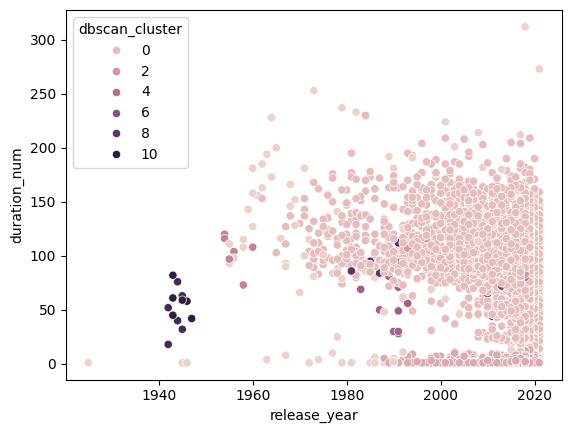

In [ ]:
sns.scatterplot(
    x='release_year',
    y='duration_num',
    hue='dbscan_cluster',
    data=df
)